In [1]:
import pandas as pd

# Load dataset
df_yield = pd.read_csv("Indian_crop_production_yield_dataset.csv")

# Preview
print(df_yield.head())

# Column names
print("Columns:", df_yield.columns)

# Info
print(df_yield.info())

# Null values
print(df_yield.isnull().sum())


                    State_Name District_Name  Crop_Year      Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000      Kharif   
1  Andaman and Nicobar Islands      NICOBARS       2000      Kharif   
2  Andaman and Nicobar Islands      NICOBARS       2000      Kharif   
3  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year   
4  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year   

                  Crop    Area  Production     yield  
0             Arecanut  1254.0      2000.0  1.594896  
1  Other Kharif pulses     2.0         1.0  0.500000  
2                 Rice   102.0       321.0  3.147059  
3               Banana   176.0       641.0  3.642045  
4            Cashewnut   720.0       165.0  0.229167  
Columns: Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production', 'yield'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575879 entries, 0 to 575878
Data columns (total 8 colu

In [2]:
# Copy dataset
df_y = df_yield.copy()

# Drop leakage columns
df_y = df_y.drop(['Production', 'Area'], axis=1)

# Check
print(df_y.head())
print("Columns:", df_y.columns)

                    State_Name District_Name  Crop_Year      Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000      Kharif   
1  Andaman and Nicobar Islands      NICOBARS       2000      Kharif   
2  Andaman and Nicobar Islands      NICOBARS       2000      Kharif   
3  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year   
4  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year   

                  Crop     yield  
0             Arecanut  1.594896  
1  Other Kharif pulses  0.500000  
2                 Rice  3.147059  
3               Banana  3.642045  
4            Cashewnut  0.229167  
Columns: Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'yield'], dtype='object')


In [3]:
print("Shape:", df_y.shape)

# Statistical summary
print(df_y.describe())

Shape: (575879, 6)
           Crop_Year         yield
count  575879.000000  5.758790e+05
mean     2007.559402  4.779376e+03
std         6.174890  7.109329e+04
min      1997.000000  0.000000e+00
25%      2002.000000  1.346025e+00
50%      2007.000000  4.484848e+01
75%      2013.000000  1.314807e+02
max      2020.000000  4.395833e+06


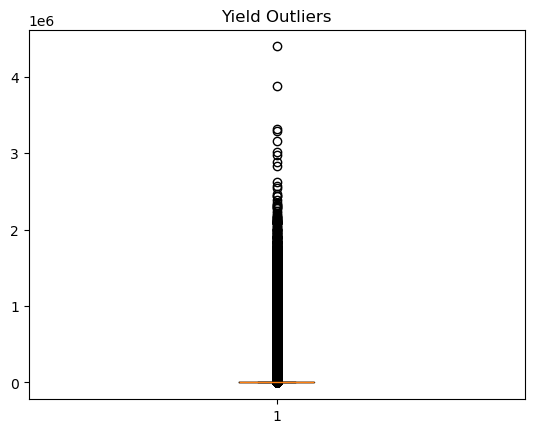

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df_y['yield'])
plt.title("Yield Outliers")
plt.show()

In [5]:
# Remove extreme values (top 1%)
upper_limit = df_y['yield'].quantile(0.99)

df_y = df_y[df_y['yield'] <= upper_limit]

print("After removing extreme outliers:", df_y.shape)

After removing extreme outliers: (570120, 6)


In [6]:
df_y = df_y.sample(n=50000, random_state=42)

print("Final shape after sampling:", df_y.shape)

Final shape after sampling: (50000, 6)


In [7]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Copy dataset
df_y_processed = df_y.copy()

# Encode categorical columns
categorical_cols = df_y_processed.select_dtypes(include=['object']).columns

encoders_yield = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_y_processed[col] = le.fit_transform(df_y_processed[col])
    encoders_yield[col] = le

# Save encoders
joblib.dump(encoders_yield, "yield_encoders.pkl")

# Split features and target
X_yield = df_y_processed.drop("yield", axis=1)
y_yield = df_y_processed["yield"]

# Save feature order
joblib.dump(X_yield.columns.tolist(), "yield_features.pkl")

print("Encoding Done ✅")
print("X shape:", X_yield.shape)
print("y shape:", y_yield.shape)

Encoding Done ✅
X shape: (50000, 5)
y shape: (50000,)


In [15]:
from sklearn.model_selection import train_test_split

X_train_y, X_test_y, y_train_y, y_test_y = train_test_split(
    X_yield, y_yield, test_size=0.2, random_state=42
)

print("X_train:", X_train_y.shape)
print("X_test :", X_test_y.shape)
print("y_train:", y_train_y.shape)
print("y_test :", y_test_y.shape)

X_train: (40000, 5)
X_test : (10000, 5)
y_train: (40000,)
y_test : (10000,)


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    print("\n==============================")
    print(f"MODEL: {name}")
    print("==============================")

    model.fit(X_train_y, y_train_y)
    y_pred = model.predict(X_test_y)

    mae = mean_absolute_error(y_test_y, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_y, y_pred))
    r2 = r2_score(y_test_y, y_pred)

    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2  : {r2:.4f}")


MODEL: Linear Regression
MAE : 308.6977
RMSE: 720.9651
R2  : 0.0465

MODEL: Random Forest
MAE : 195.7450
RMSE: 598.8792
R2  : 0.3421

MODEL: Gradient Boosting
MAE : 228.1305
RMSE: 587.8213
R2  : 0.3662


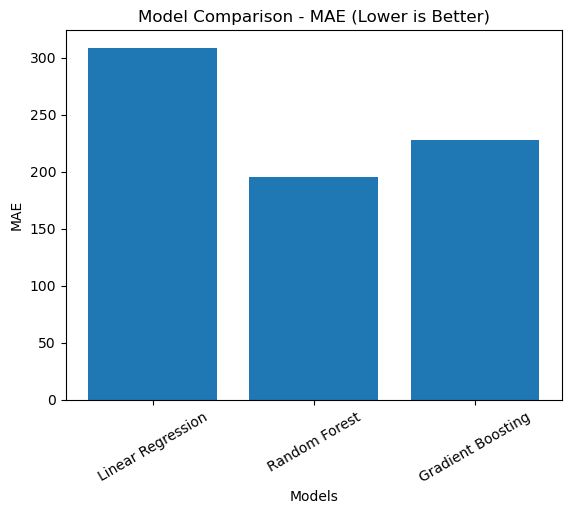

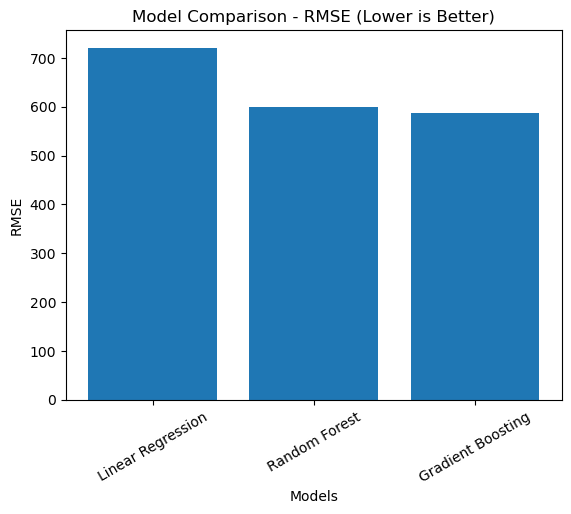

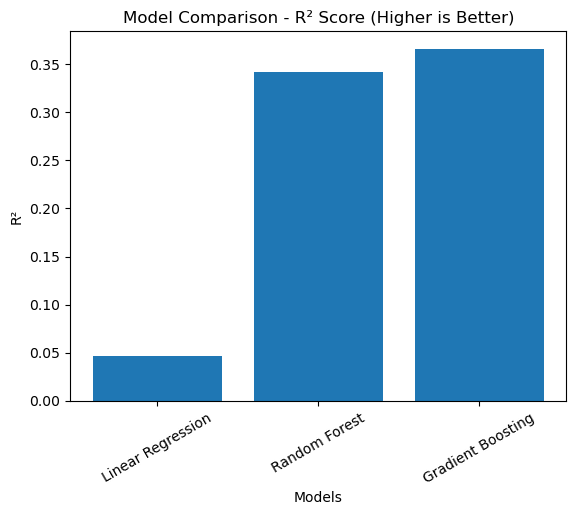

In [10]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Random Forest", "Gradient Boosting"]

mae = [308.6977, 195.7450, 228.1305]
rmse = [720.9651, 598.8792, 587.8213]
r2 = [0.0465, 0.3421, 0.3662]

# MAE Plot
plt.figure()
plt.bar(models, mae)
plt.title("Model Comparison - MAE (Lower is Better)")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.xticks(rotation=30)
plt.show()

# RMSE Plot
plt.figure()
plt.bar(models, rmse)
plt.title("Model Comparison - RMSE (Lower is Better)")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()

# R2 Plot
plt.figure()
plt.bar(models, r2)
plt.title("Model Comparison - R² Score (Higher is Better)")
plt.xlabel("Models")
plt.ylabel("R²")
plt.xticks(rotation=30)
plt.show()

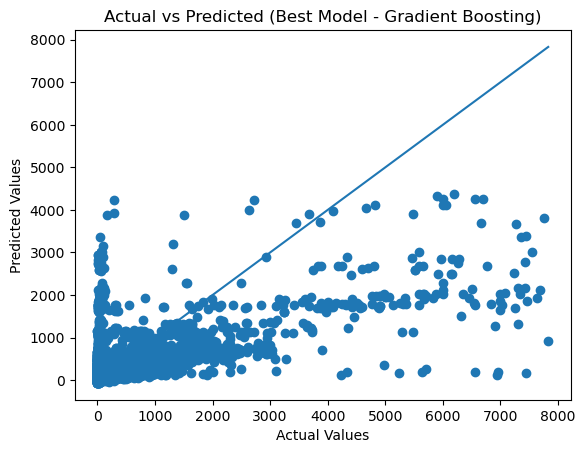

In [18]:
best_model = GradientBoostingRegressor(random_state=42)
best_model.fit(X_train_y, y_train_y)
y_pred = best_model.predict(X_test_y)

plt.figure()
plt.scatter(y_test_y, y_pred)
plt.plot([y_test_y.min(), y_test_y.max()],
         [y_test_y.min(), y_test_y.max()])
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Best Model - Gradient Boosting)")
plt.show()

In [12]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)

cv_scores = cross_val_score(
    gb_model,
    X_yield,
    y_yield,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", cv_scores)
print("Average R2 Score:", cv_scores.mean())

Cross Validation Scores: [0.40005199 0.41165842 0.42056744 0.41405694 0.44108702]
Average R2 Score: 0.4174843594929829


In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    gb,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_y, y_train_y)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 150}
Best Score: 0.4998115171433028


In [14]:
from sklearn.ensemble import GradientBoostingRegressor
import joblib

# Train final model with best parameters
final_yield_model = GradientBoostingRegressor(
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=2,
    n_estimators=150,
    random_state=42
)

final_yield_model.fit(X_yield, y_yield)

# Save final yield model
joblib.dump(final_yield_model, "yield_model.pkl")

print("Yield model saved!")

Yield model saved!


In [19]:
def predict_yield_final(crop, temperature, rainfall, state, district, year=2020):

    input_data = {
        'Crop': crop,
        'Crop_Year': year,
        'Season': 'Kharif',
        'State_Name': state,
        'District_Name': district
    }

    df_input = pd.DataFrame([input_data])

    # Safe encoding
    for col in yield_encoders:
        if col in df_input:
            if df_input[col][0] in yield_encoders[col].classes_:
                df_input[col] = yield_encoders[col].transform(df_input[col])
            else:
                df_input[col] = 0

    df_input = df_input.reindex(columns=yield_features)

    predicted_yield = yield_model.predict(df_input)[0]

    return predicted_yield